# Breast Tumor Classification: Dataset Understanding

## Objective

This notebook establishes the dataset, its structure, data quality, and
classification target before any machine-learning model is developed.

The project investigates how model evaluation and validation methodology
affect the apparent reliability of breast-tumor classification models.

### Questions addressed in this notebook

- Where does the dataset come from?
- What does each feature represent?
- How many observations and variables are present?
- What is the target variable?
- Are there missing or invalid observations?
- How are the classes distributed?
- Does the dataset contain chronological information that can support
  alternative validation strategies?

No model training is performed in this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready.")



Environment ready.


In [2]:
from ucimlrepo import fetch_ucirepo

# Fetch the Wisconsin Breast Cancer (Original) dataset
breast_cancer = fetch_ucirepo(id=15)

X = breast_cancer.data.features
y = breast_cancer.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nFirst five observations:")
display(X.head())

print("\nTarget values:")
display(y.head())
print("\nFeature data types:")
print(X.dtypes)

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget data types:")
print(y.dtypes)

print("\nTarget distribution:")
print(y["Class"].value_counts())
print("\nDataset metadata:")
print(breast_cancer.metadata.additional_info)

Features shape: (699, 9)
Target shape: (699, 1)

Feature names:
['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']

First five observations:


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1



Target values:


,Class
0,2
1,2
2,2
3,2
4,2



Feature data types:
Clump_thickness                  int64
Uniformity_of_cell_size          int64
Uniformity_of_cell_shape         int64
Marginal_adhesion                int64
Single_epithelial_cell_size      int64
Bare_nuclei                    float64
Bland_chromatin                  int64
Normal_nucleoli                  int64
Mitoses                          int64
dtype: object

Missing values:
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

Target data types:
Class    int64
dtype: object

Target distribution:
Class
2    458
4    241
Name: count, dtype: int64

Dataset metadata:
{'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological gro

## Dataset provenance and structure

The primary dataset is the Wisconsin Breast Cancer (Original) dataset
obtained through the UCI Machine Learning Repository.

The dataset contains 699 observations and 9 predictor variables. The
predictors represent cytological characteristics recorded on a 1–10 scale.

The target variable `Class` is encoded as:

- `2` — benign
- `4` — malignant

The dataset contains 16 missing observations in `Bare_nuclei`.

### Chronological structure

The UCI metadata states that samples arrived periodically and provides
eight chronological groups spanning January 1989 to November 1991.

These group labels are not included in the feature table returned by the
dataset loader. Therefore, the chronological information will not be
treated as an available row-level variable unless the original grouping
can be reconstructed from a documented source.

This is important for the later validation analysis: we will distinguish
between ordinary random validation and any genuinely documented
cross-period evaluation rather than assuming that the current row order
represents time.

### Initial data-quality observations

At this stage, no observations have been removed and no missing values
have been imputed. All preprocessing decisions will be made explicitly
and, where appropriate, using training data only to avoid information
leakage.

In [3]:
# Summary statistics for the predictor variables
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Clump_thickness,699.0,4.417740,2.815741,1.0,2.0,4.0,6.0,10.0
Uniformity_of_cell_size,699.0,3.134478,3.051459,1.0,1.0,1.0,5.0,10.0
Uniformity_of_cell_shape,699.0,3.207439,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal_adhesion,699.0,2.806867,2.855379,1.0,1.0,1.0,4.0,10.0
Single_epithelial_cell_size,699.0,3.216023,2.214300,1.0,2.0,2.0,4.0,10.0
Bare_nuclei,683.0,3.544656,3.643857,1.0,1.0,1.0,6.0,10.0
Bland_chromatin,699.0,3.437768,2.438364,1.0,2.0,3.0,5.0,10.0
Normal_nucleoli,699.0,2.866953,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413,1.715078,1.0,1.0,1.0,1.0,10.0


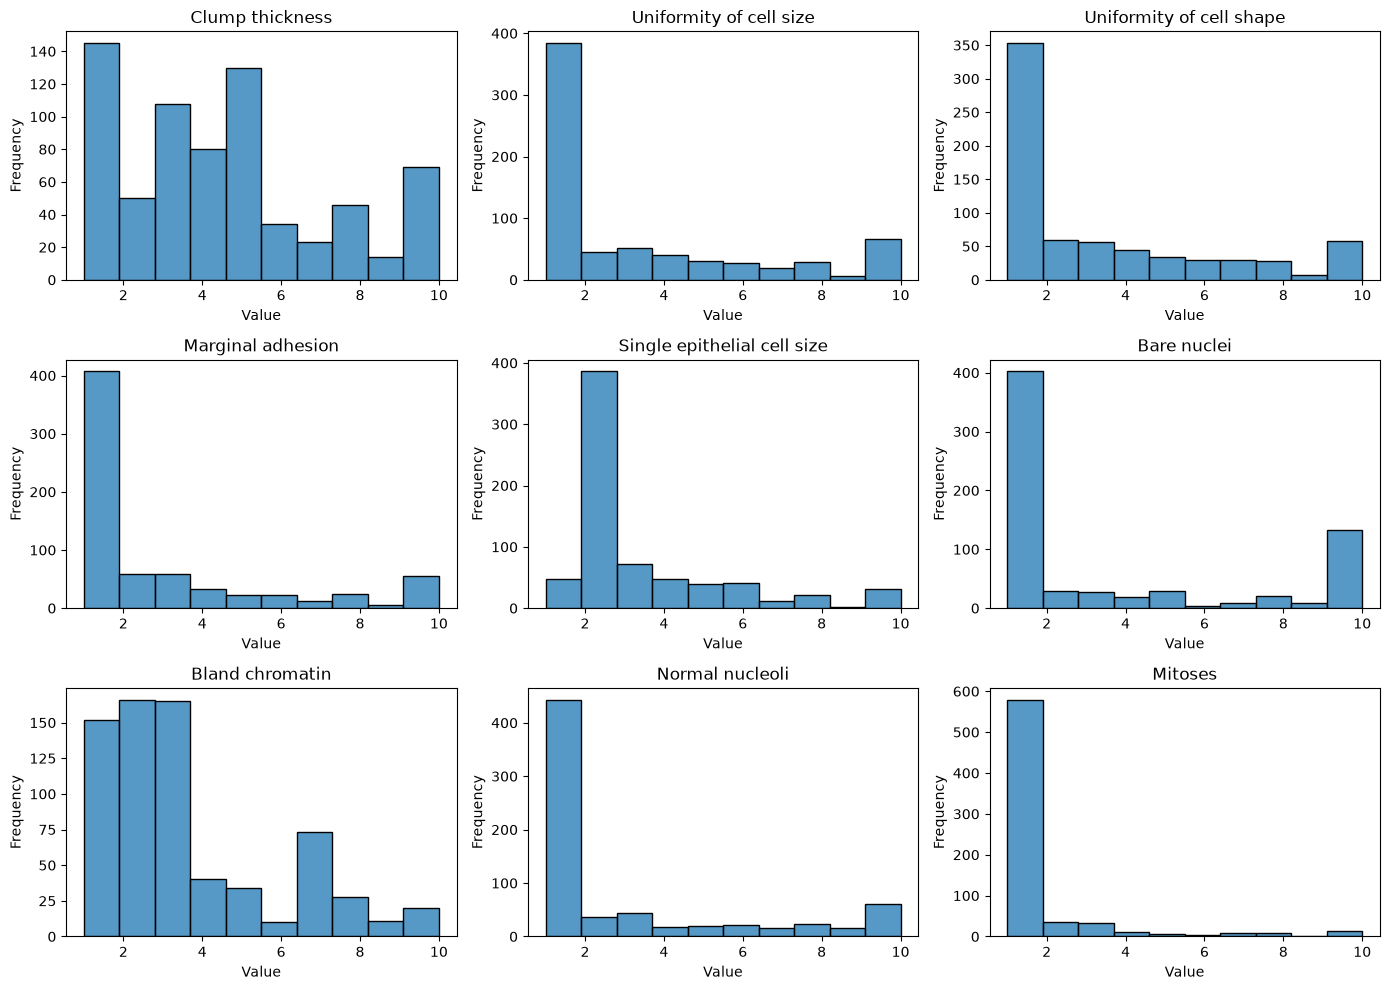

In [4]:
# Visualize the distributions of the predictor variables

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    sns.histplot(X[column], bins=10, ax=axes[i])
    axes[i].set_title(column.replace("_", " "))
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

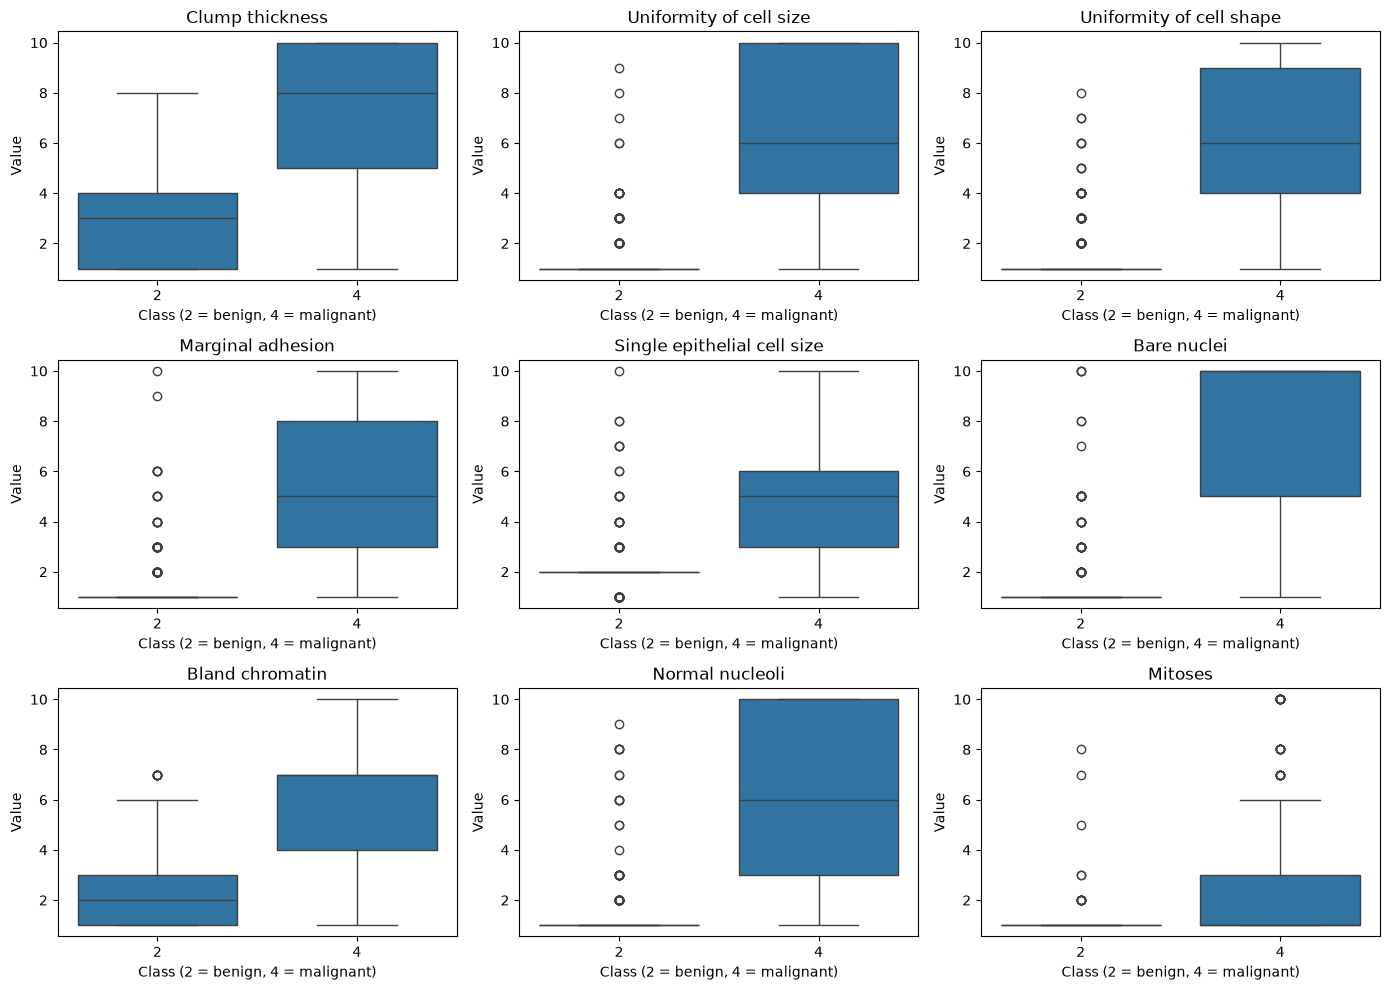

In [5]:
# Compare feature distributions between benign and malignant cases

X_with_target = X.copy()
X_with_target["Class"] = y["Class"].values

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    sns.boxplot(
        data=X_with_target,
        x="Class",
        y=column,
        ax=axes[i]
    )
    axes[i].set_title(column.replace("_", " "))
    axes[i].set_xlabel("Class (2 = benign, 4 = malignant)")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()

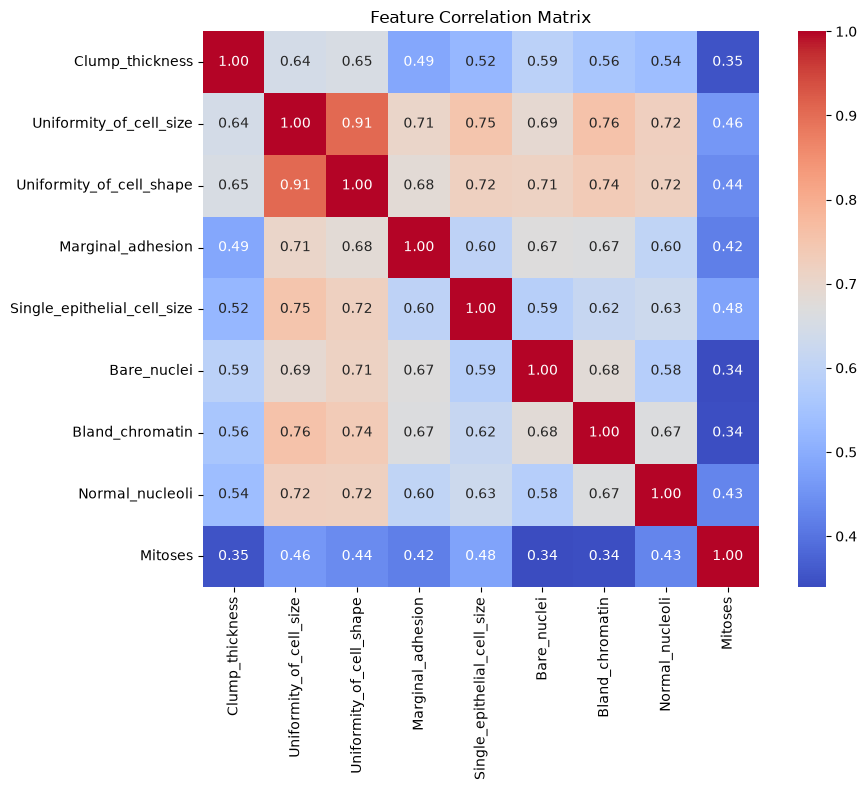

In [6]:
# Correlation between predictor variables

correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature correlation

The predictor correlation matrix shows substantial dependence among
several features.

The strongest pairwise correlation is between `Uniformity_of_cell_size`
and `Uniformity_of_cell_shape` (r = 0.91). Several other feature pairs
show moderate-to-strong positive correlations.

This indicates that some predictors contain overlapping information.
However, correlated features are not removed solely on the basis of this
analysis. Their effect on model estimation, predictive performance, and
interpretability may differ across model families.

Therefore, feature selection or removal will not be performed at this
stage. The baseline models will initially use the available predictors,
with model-specific preprocessing applied where appropriate.

In [7]:
# Compare each feature between the two tumor classes

class_summary = pd.DataFrame(index=X.columns)

class_summary["Benign_mean"] = X[y["Class"] == 2].mean()
class_summary["Malignant_mean"] = X[y["Class"] == 4].mean()

class_summary["Benign_median"] = X[y["Class"] == 2].median()
class_summary["Malignant_median"] = X[y["Class"] == 4].median()

class_summary["Mean_difference"] = (
    class_summary["Malignant_mean"] -
    class_summary["Benign_mean"]
)

class_summary.round(3)

,Benign_mean,Malignant_mean,Benign_median,Malignant_median,Mean_difference
Clump_thickness,2.956,7.195,3.0,8.0,4.239
Uniformity_of_cell_size,1.325,6.573,1.0,6.0,5.247
Uniformity_of_cell_shape,1.443,6.560,1.0,6.0,5.117
Marginal_adhesion,1.365,5.548,1.0,5.0,4.183
Single_epithelial_cell_size,2.120,5.299,2.0,5.0,3.179
Bare_nuclei,1.347,7.628,1.0,10.0,6.281
Bland_chromatin,2.100,5.979,2.0,7.0,3.879
Normal_nucleoli,1.290,5.863,1.0,6.0,4.573
Mitoses,1.063,2.589,1.0,1.0,1.526


## Class-conditional feature comparison

The class-conditional descriptive statistics show substantial differences
between the benign and malignant groups across several predictors.

The largest raw mean differences are observed for `Bare_nuclei`,
`Uniformity_of_cell_size`, and `Uniformity_of_cell_shape`. However, these
differences should not be interpreted as model feature importance because
the predictors are correlated and the analysis is univariate.

`Mitoses` shows a smaller difference in mean values and identical medians
of 1 for both classes, indicating that its distribution is concentrated
near the lower end of the measurement scale despite differences in its
upper tail.

The `Bare_nuclei` statistics are based on 683 non-missing observations,
while the remaining features contain 699 observations.

In [8]:
# Inspect observations with missing Bare_nuclei values

missing_bare_nuclei = X[X["Bare_nuclei"].isna()].copy()

print("Number of observations with missing Bare_nuclei:",
      len(missing_bare_nuclei))

display(missing_bare_nuclei)

print("\nClass distribution of observations with missing Bare_nuclei:")
display(y.loc[missing_bare_nuclei.index].value_counts())

Number of observations with missing Bare_nuclei: 16


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
23,8,4,5,1,2,NaN,7,3,1
40,6,6,6,9,6,NaN,7,8,1
139,1,1,1,1,1,NaN,2,1,1
145,1,1,3,1,2,NaN,2,1,1
158,1,1,2,1,3,NaN,1,1,1
164,5,1,1,1,2,NaN,3,1,1
235,3,1,4,1,2,NaN,3,1,1
249,3,1,1,1,2,NaN,3,1,1
275,3,1,3,1,2,NaN,2,1,1
292,8,8,8,1,2,NaN,6,10,1



Class distribution of observations with missing Bare_nuclei:


Class
2        14
4         2
Name: count, dtype: int64

## Missing-value investigation

Sixteen observations have missing values for `Bare_nuclei`, corresponding
to approximately 2.3% of the dataset.

Among these observations, 14 are classified as benign and 2 as malignant.
The remaining predictor values vary considerably across the incomplete
observations, so the missing values cannot be reliably reconstructed from
a simple deterministic rule.

The primary modeling analysis will therefore use median imputation for
`Bare_nuclei`.

To avoid information leakage, the imputation value will be estimated
from the training data only and then applied to validation or test data
within a preprocessing pipeline.

A complete-case sensitivity analysis will also be considered to assess
whether conclusions are materially affected by the treatment of these
16 observations.

The class label will not be used to determine imputed feature values.


In [9]:
# Convert the original UCI class labels to binary labels

y_binary = y["Class"].map({
    2: 0,   # benign
    4: 1    # malignant
})

print("Original labels:")
print(y["Class"].value_counts().sort_index())

print("\nBinary labels:")
print(y_binary.value_counts().sort_index())

print("\nMissing target values:", y_binary.isna().sum())

Original labels:
Class
2    458
4    241
Name: count, dtype: int64

Binary labels:
Class
0    458
1    241
Name: count, dtype: int64

Missing target values: 0


## Target encoding

The original UCI target uses the labels `2` for benign and `4` for
malignant.

For modeling, these labels are mapped to a binary target:

- `0` — benign
- `1` — malignant

The original target variable is preserved, while `y_binary` is used for
subsequent machine-learning analysis.

There are no missing target values.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    stratify=y_binary,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (559, 9)
Test set: (140, 9)

Training class distribution:
Class
0    0.654741
1    0.345259
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.657143
1    0.342857
Name: proportion, dtype: float64


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Median imputation for missing feature values.
# The median will be learned from X_train only.
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Training data shape after imputation:", X_train_imputed.shape)
print("Test data shape after imputation:", X_test_imputed.shape)

print("\nMissing values after imputation:")
print("Training:", np.isnan(X_train_imputed).sum())
print("Test:", np.isnan(X_test_imputed).sum())

Training data shape after imputation: (559, 9)
Test data shape after imputation: (140, 9)

Missing values after imputation:
Training: 0
Test: 0


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# Models that benefit from feature scaling
scaled_models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", CalibratedClassifierCV(
            estimator=SVC(),
            cv=5,
            method="sigmoid"
        ))
    ])
}


# Tree-based models do not require feature scaling
tree_models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}


models = {**scaled_models, **tree_models}

print("Baseline pipelines:")
for name in models:
    print("-", name)

Baseline pipelines:
- Logistic Regression
- SVM
- Decision Tree
- Random Forest


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

results = []
predictions = {}

for name, pipeline in models.items():
    # Train only on the training data
    pipeline.fit(X_train, y_train)

    # Predict the untouched test set
    y_pred = pipeline.predict(X_test)

    # Probability/score for the positive class
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    predictions[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Sensitivity": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,MCC
0,Logistic Regression,0.9500,0.9362,0.9167,0.9674,0.9263,0.9950,0.8886
1,SVM,0.9643,0.9388,0.9583,0.9674,0.9485,0.9896,0.9213
2,Decision Tree,0.9286,0.9318,0.8542,0.9674,0.8913,0.9108,0.8400
3,Random Forest,0.9571,0.9375,0.9375,0.9674,0.9375,0.9914,0.9049


## Baseline Model Evaluation — Interpretation

Four baseline classifiers were evaluated using a stratified 80/20
train-test split:

- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

Missing values were handled through model pipelines, with the imputation
step fitted using training data only. Standardization was applied to the
Logistic Regression and SVM pipelines.

The initial hold-out results show strong discrimination across all four
models. However, these results are based on a single random train-test
split and should not be interpreted as definitive evidence that one model
is superior.

Subsequent analyses examine performance under repeated validation,
threshold variation, calibration, and error analysis.

## Cross-Validation

A single train-test split provides only one estimate of model performance.
To assess the stability of the observed results across different data
partitions, repeated stratified cross-validation is used.

Five-fold stratified cross-validation is repeated five times, producing
25 validation folds for each model.

The preprocessing steps remain inside each model pipeline so that
imputation and standardization are fitted independently within each
training fold, preventing information from the validation fold from
entering preprocessing.

Performance is summarized using the mean and standard deviation across
the repeated validation folds.

In [14]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, confusion_matrix


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fp)


scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "specificity": make_scorer(specificity_score),
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "mcc": make_scorer(matthews_corrcoef)
}


cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)


cv_results = {}

for name, pipeline in models.items():

    scores = cross_validate(
        pipeline,
        X,
        y_binary,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[name] = scores


cv_summary = []

for name, scores in cv_results.items():

    for metric in scoring.keys():

        values = scores[f"test_{metric}"]

        cv_summary.append({
            "Model": name,
            "Metric": metric,
            "Mean": values.mean(),
            "Std": values.std()
        })


cv_summary_df = pd.DataFrame(cv_summary)

cv_summary_df.round(4)

,Model,Metric,Mean,Std
0,Logistic Regression,accuracy,0.9674,0.0097
1,Logistic Regression,precision,0.9548,0.0216
2,Logistic Regression,sensitivity,0.9511,0.0268
3,Logistic Regression,specificity,0.9760,0.0120
4,Logistic Regression,f1,0.9525,0.0143
5,Logistic Regression,roc_auc,0.9947,0.0031
6,Logistic Regression,pr_auc,0.9891,0.0072
7,Logistic Regression,mcc,0.9281,0.0216
8,SVM,accuracy,0.9665,0.0086
9,SVM,precision,0.9354,0.0256


## Cross-Validation Results

Repeated stratified five-fold cross-validation was performed five times,
resulting in 25 validation evaluations for each model.

The cross-validation results show broadly consistent performance patterns
across the repeated folds. Logistic Regression, SVM, and Random Forest
maintained high discrimination and classification performance, while the
Decision Tree showed lower performance across several metrics.

The standard deviations provide an estimate of performance variability
across the repeated validation folds. The relatively small variability
observed for most metrics indicates that the measured performance was not
strongly dependent on a particular validation partition.

The repeated-validation results are broadly consistent with the initial
80/20 hold-out evaluation. However, the results should be interpreted as
estimates of performance on this dataset rather than evidence of clinical
performance or generalization to an external patient population.

In [15]:
# Metrics available in both hold-out evaluation and cross-validation
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "MCC"
]


# -----------------------------
# Hold-out results
# -----------------------------

holdout_table = results_df.set_index("Model")[
    comparison_metrics
].rename(
    columns={
        metric: f"Holdout_{metric}"
        for metric in comparison_metrics
    }
)


# -----------------------------
# Cross-validation mean results
# -----------------------------

cv_mean_table = cv_summary_df.pivot(
    index="Model",
    columns="Metric",
    values="Mean"
)

cv_mean_table = cv_mean_table[
    [metric.lower() for metric in comparison_metrics]
].rename(
    columns={
        metric.lower(): f"CV_{metric}_Mean"
        for metric in comparison_metrics
    }
)


# -----------------------------
# Cross-validation standard deviation
# -----------------------------

cv_std_table = cv_summary_df.pivot(
    index="Model",
    columns="Metric",
    values="Std"
)

cv_std_table = cv_std_table[
    [metric.lower() for metric in comparison_metrics]
].rename(
    columns={
        metric.lower(): f"CV_{metric}_Std"
        for metric in comparison_metrics
    }
)


# -----------------------------
# Combine the results
# -----------------------------

validation_comparison = (
    holdout_table
    .join(cv_mean_table)
    .join(cv_std_table)
)


validation_comparison.round(4)

,Holdout_Accuracy,Holdout_Precision,Holdout_Sensitivity,Holdout_Specificity,Holdout_F1,Holdout_ROC_AUC,Holdout_MCC,CV_Accuracy_Mean,CV_Precision_Mean,CV_Sensitivity_Mean,...,CV_F1_Mean,CV_ROC_AUC_Mean,CV_MCC_Mean,CV_Accuracy_Std,CV_Precision_Std,CV_Sensitivity_Std,CV_Specificity_Std,CV_F1_Std,CV_ROC_AUC_Std,CV_MCC_Std
Model,,,,,,,,,,,,,,,,,,,,,
Logistic Regression,0.9500,0.9362,0.9167,0.9674,0.9263,0.9950,0.8886,0.9674,0.9548,0.9511,...,0.9525,0.9947,0.9281,0.0097,0.0216,0.0268,0.0120,0.0143,0.0031,0.0216
SVM,0.9643,0.9388,0.9583,0.9674,0.9485,0.9896,0.9213,0.9665,0.9354,0.9710,...,0.9525,0.9901,0.9275,0.0086,0.0256,0.0165,0.0157,0.0115,0.0059,0.0176
Decision Tree,0.9286,0.9318,0.8542,0.9674,0.8913,0.9108,0.8400,0.9356,0.9234,0.8886,...,0.9044,0.9244,0.8576,0.0181,0.0335,0.0511,0.0193,0.0289,0.0243,0.0403
Random Forest,0.9571,0.9375,0.9375,0.9674,0.9375,0.9914,0.9049,0.9677,0.9455,0.9627,...,0.9536,0.9920,0.9293,0.0104,0.0262,0.0220,0.0154,0.0146,0.0044,0.0224


## Classification Threshold Analysis

Binary classifiers commonly convert predicted probabilities into class
labels using a default threshold of 0.50. However, changing this threshold
changes the balance between sensitivity and specificity.

This analysis examines how classification performance changes across a range
of probability thresholds.

The threshold analysis is treated as an exploratory analysis of the
untouched test set. No threshold is selected or optimized using the test
set, so the test data remain reserved for final evaluation.

In [16]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for name, prediction_data in predictions.items():

    y_prob = prediction_data["y_prob"]

    for threshold in thresholds:

        y_threshold = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_threshold
        ).ravel()

        specificity = tn / (tn + fp)

        threshold_results.append({
            "Model": name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_test, y_threshold),
            "Precision": precision_score(
                y_test,
                y_threshold,
                zero_division=0
            ),
            "Sensitivity": recall_score(
                y_test,
                y_threshold,
                zero_division=0
            ),
            "Specificity": specificity,
            "F1": f1_score(
                y_test,
                y_threshold,
                zero_division=0
            ),
            "False_Positive_Rate": fp / (fp + tn),
            "False_Negative_Rate": fn / (fn + tp)
        })


threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Model,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,False_Positive_Rate,False_Negative_Rate
0,Logistic Regression,0.10,0.9643,0.9216,0.9792,0.9565,0.9495,0.0435,0.0208
1,Logistic Regression,0.15,0.9714,0.9400,0.9792,0.9674,0.9592,0.0326,0.0208
2,Logistic Regression,0.20,0.9714,0.9400,0.9792,0.9674,0.9592,0.0326,0.0208
3,Logistic Regression,0.25,0.9643,0.9388,0.9583,0.9674,0.9485,0.0326,0.0417
4,Logistic Regression,0.30,0.9571,0.9375,0.9375,0.9674,0.9375,0.0326,0.0625
...,...,...,...,...,...,...,...,...,...
63,Random Forest,0.70,0.9214,0.9302,0.8333,0.9674,0.8791,0.0326,0.1667
64,Random Forest,0.75,0.9143,0.9286,0.8125,0.9674,0.8667,0.0326,0.1875
65,Random Forest,0.80,0.9143,0.9286,0.8125,0.9674,0.8667,0.0326,0.1875
66,Random Forest,0.85,0.9214,0.9512,0.8125,0.9783,0.8764,0.0217,0.1875


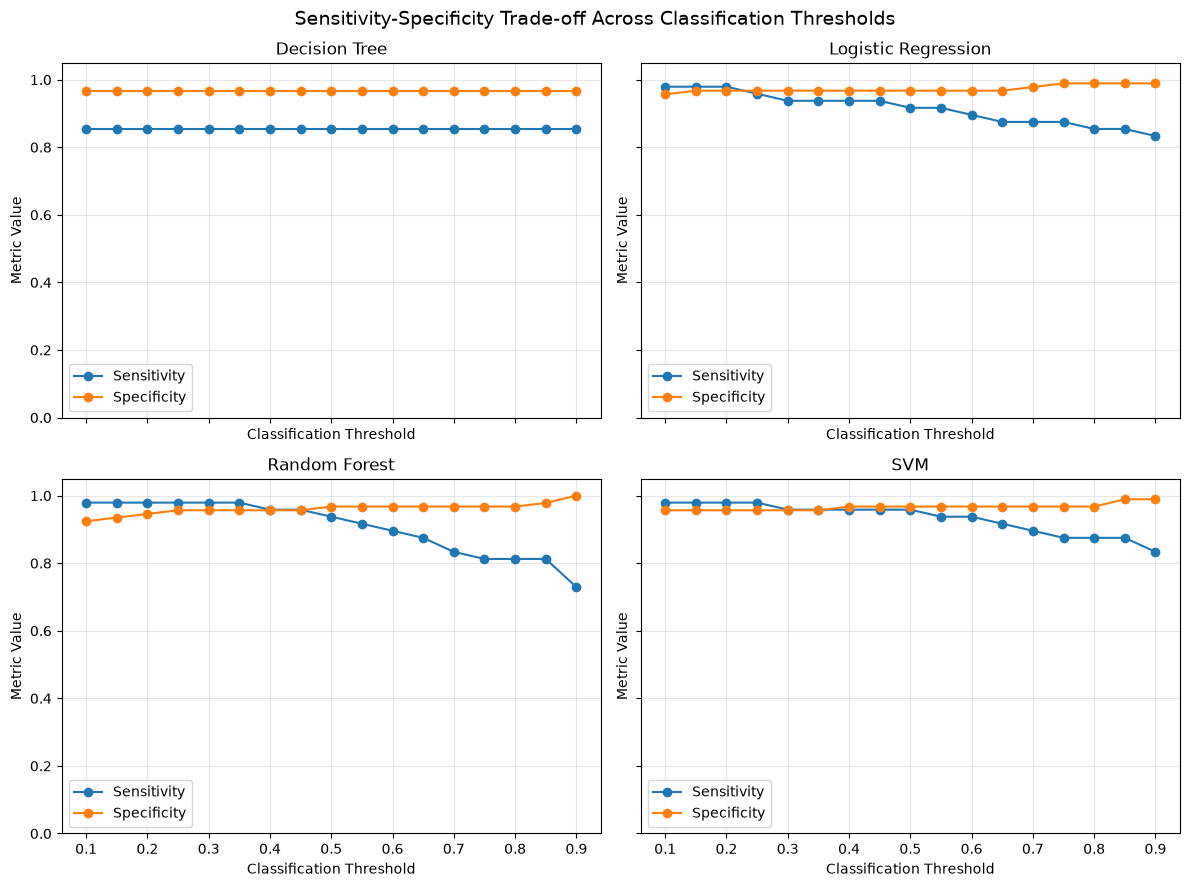

In [17]:
#Threshold Analysis Visualization
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, (name, group) in zip(
    axes,
    threshold_df.groupby("Model")
):

    ax.plot(
        group["Threshold"],
        group["Sensitivity"],
        marker="o",
        label="Sensitivity"
    )

    ax.plot(
        group["Threshold"],
        group["Specificity"],
        marker="o",
        label="Specificity"
    )

    ax.set_title(name)
    ax.set_xlabel("Classification Threshold")
    ax.set_ylabel("Metric Value")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()


plt.suptitle(
    "Sensitivity-Specificity Trade-off Across Classification Thresholds",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Threshold Analysis — Interpretation

The threshold analysis demonstrates that classification performance is
threshold-dependent. Changing the probability threshold alters the balance
between sensitivity and specificity and consequently changes the rates of
false-negative and false-positive predictions.

For Logistic Regression, SVM, and Random Forest, increasing the threshold
generally reduces sensitivity while maintaining or increasing specificity.
This illustrates the trade-off between detecting more malignant cases and
reducing false-positive classifications.

The Decision Tree shows a more step-like threshold response because its
predicted probabilities take a limited number of discrete values. Therefore,
changing the threshold does not necessarily change predictions at every
threshold value.

The results demonstrate why accuracy at the default threshold alone does
not fully describe classifier behavior.

No threshold was selected or optimized using the test set. This analysis
is therefore treated as an exploratory examination of threshold behavior
rather than a threshold-selection procedure.

## Probability Calibration

Classification models can produce probability estimates in addition to
class predictions. A well-calibrated model should produce probabilities
that correspond reasonably closely to observed event frequencies.

For example, among observations assigned a predicted probability of 0.70,
approximately 70% would be expected to belong to the positive class if the
model is well calibrated.

Calibration is therefore evaluated separately from discrimination metrics
such as ROC-AUC. A model can discriminate well between classes while still
producing poorly calibrated probabilities.

Calibration performance will be examined using the Brier score and
calibration curves on the held-out test set.


In [18]:
#Probability Calibration Analysis
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

calibration_results = []

for name, prediction_data in predictions.items():

    y_prob = prediction_data["y_prob"]

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    calibration_results.append({
        "Model": name,
        "Brier_Score": brier
    })


calibration_df = pd.DataFrame(calibration_results)

calibration_df.round(4)

,Model,Brier_Score
0,Logistic Regression,0.0327
1,SVM,0.0333
2,Decision Tree,0.0714
3,Random Forest,0.0363


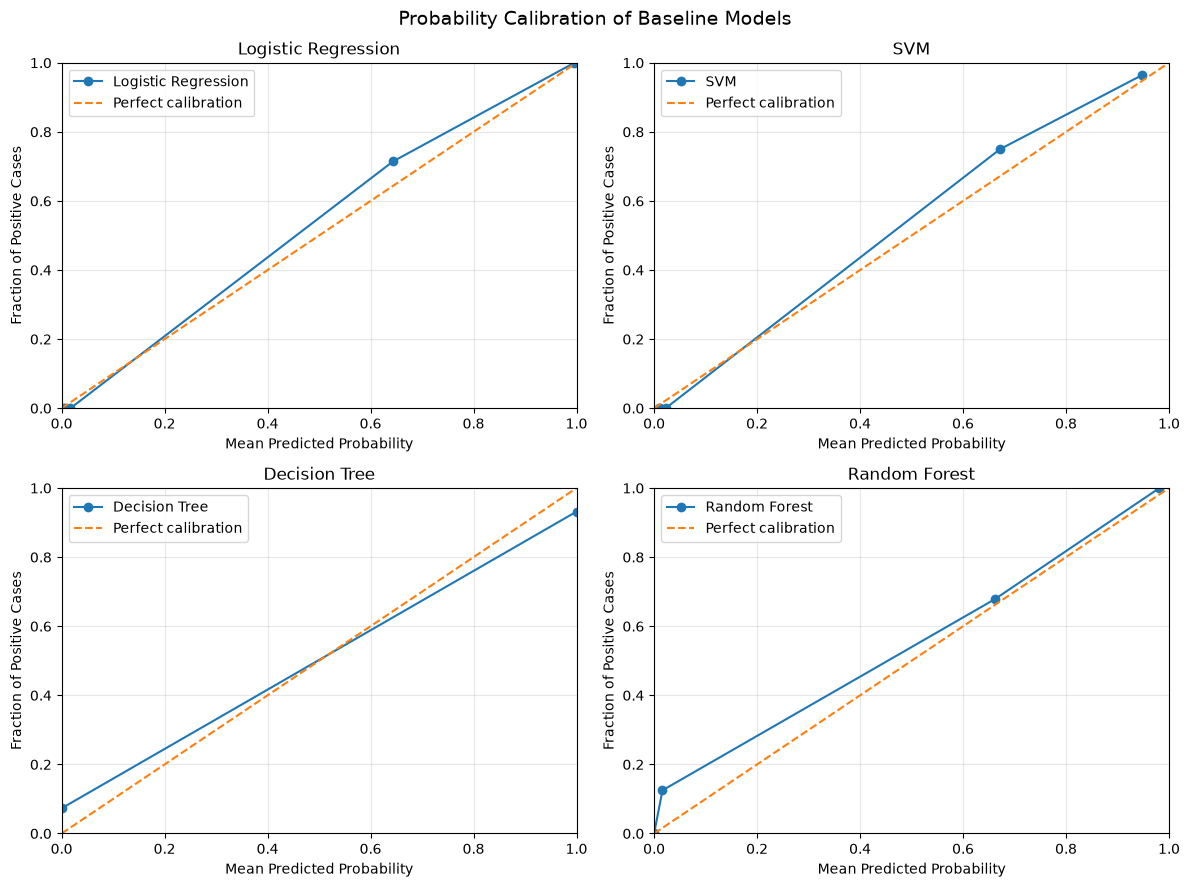

In [19]:
#Calibration Curves
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.ravel()

for ax, (name, prediction_data) in zip(
    axes,
    predictions.items()
):

    y_prob = prediction_data["y_prob"]

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        y_prob,
        n_bins=5,
        strategy="quantile"
    )

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        label=name
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    ax.set_title(name)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positive Cases")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()


plt.suptitle(
    "Probability Calibration of Baseline Models",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Probability Calibration — Interpretation

The calibration analysis evaluates whether predicted probabilities correspond
reasonably to the observed frequency of malignant cases.

The Brier scores provide a quantitative measure of probabilistic prediction
error, while the calibration curves provide a visual assessment of the
relationship between predicted probabilities and observed frequencies.

The calibration curves are generally close to the perfect-calibration
reference line in the probability regions represented by the held-out test
set. However, the curves should be interpreted cautiously because they are
estimated from a relatively small test set.

The results demonstrate that discrimination and calibration are distinct
properties. A model may achieve high ROC-AUC while its predicted
probabilities do not correspond perfectly to observed frequencies.

Therefore, classification performance and probability reliability are
examined separately in this study.

## Neural Network Model Complexity

The baseline experiments used classical machine-learning models that are
well suited to small tabular datasets. A neural network is introduced as a
controlled model-complexity experiment rather than as an assumption that
greater complexity will improve classification performance.

Because the dataset contains only nine numerical predictors and a relatively
small number of observations, increasing neural-network depth may increase
the risk of overfitting without providing meaningful performance gains.

This experiment therefore examines how neural-network architecture and
regularization affect predictive performance, stability, and probability
calibration.

Candidate architectures differ in the number and size of hidden layers.
Architecture selection is performed using the training data through
cross-validation. The held-out test set is not used to select the neural
network architecture.

The experiment addresses the following question:

> Does increasing neural-network complexity produce meaningful and reliable
> improvements in breast-tumor classification on this small tabular dataset?

In [20]:
#Neural Network Architectures
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# Candidate neural-network architectures
mlp_architectures = {
    "MLP - 1 Hidden Layer": (32,),
    "MLP - 2 Hidden Layers": (32, 16),
    "MLP - 3 Hidden Layers": (32, 16, 8)
}


mlp_models = {}

for name, architecture in mlp_architectures.items():

    mlp_models[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler()),

        ("model", MLPClassifier(
            hidden_layer_sizes=architecture,
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=32,
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42
        ))
    ])


print("Candidate neural-network architectures:\n")

for name, architecture in mlp_architectures.items():
    print(f"{name}: {architecture}")

Candidate neural-network architectures:

MLP - 1 Hidden Layer: (32,)
MLP - 2 Hidden Layers: (32, 16)
MLP - 3 Hidden Layers: (32, 16, 8)


In [21]:
# Neural Network Cross-Validation Experiment

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, confusion_matrix


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fp)


mlp_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "sensitivity": "recall",
    "specificity": make_scorer(specificity_score),
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "mcc": make_scorer(matthews_corrcoef)
}


mlp_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)


mlp_cv_results = {}

for name, pipeline in mlp_models.items():

    scores = cross_validate(
        pipeline,
        X,
        y_binary,
        cv=mlp_cv,
        scoring=mlp_scoring,
        n_jobs=-1
    )

    mlp_cv_results[name] = scores


mlp_cv_summary = []

for name, scores in mlp_cv_results.items():

    for metric in mlp_scoring.keys():

        values = scores[f"test_{metric}"]

        mlp_cv_summary.append({
            "Model": name,
            "Metric": metric,
            "Mean": values.mean(),
            "Std": values.std()
        })


mlp_cv_summary_df = pd.DataFrame(mlp_cv_summary)

mlp_cv_summary_df.round(4)

,Model,Metric,Mean,Std
0,MLP - 1 Hidden Layer,accuracy,0.9656,0.0142
1,MLP - 1 Hidden Layer,precision,0.9314,0.0258
2,MLP - 1 Hidden Layer,sensitivity,0.9726,0.0267
3,MLP - 1 Hidden Layer,specificity,0.9620,0.0149
4,MLP - 1 Hidden Layer,f1,0.9513,0.0201
5,MLP - 1 Hidden Layer,roc_auc,0.9915,0.0050
6,MLP - 1 Hidden Layer,pr_auc,0.9820,0.0113
7,MLP - 1 Hidden Layer,mcc,0.9257,0.0312
8,MLP - 2 Hidden Layers,accuracy,0.9619,0.0181
9,MLP - 2 Hidden Layers,precision,0.9438,0.0229


## Neural Network Complexity — Interpretation

The neural-network experiment evaluated three progressively deeper MLP
architectures using repeated stratified five-fold cross-validation.

Increasing the number of hidden layers did not produce a consistent
improvement across the evaluation metrics. The one-hidden-layer MLP achieved
higher mean accuracy, sensitivity, F1, and MCC than the deeper architectures,
while the two- and three-hidden-layer models produced slightly higher mean
ROC-AUC and PR-AUC values.

The deeper architectures also showed greater variability in sensitivity
across validation folds. This indicates that increasing network depth did
not automatically improve the stability of classification performance on
this small tabular dataset.

These results illustrate an important model-complexity trade-off: a more
complex neural network can improve some aspects of probabilistic
discrimination while providing no consistent improvement in classification
performance or stability.

The experiment therefore provides no evidence from this dataset alone that
additional MLP depth is necessary for improved predictive performance.

Further analysis will examine probability calibration and prediction errors
before drawing conclusions about the neural-network models.

In [22]:
# Neural Network Probability Calibration

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


mlp_calibration_results = []

for name, pipeline in mlp_models.items():

    # Fit only on the training portion
    pipeline.fit(X_train, y_train)

    # Predict probabilities on the held-out test set
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    mlp_calibration_results.append({
        "Model": name,
        "Brier_Score": brier
    })


mlp_calibration_df = pd.DataFrame(
    mlp_calibration_results
)

mlp_calibration_df.round(4)

,Model,Brier_Score
0,MLP - 1 Hidden Layer,0.0796
1,MLP - 2 Hidden Layers,0.0306
2,MLP - 3 Hidden Layers,0.0321


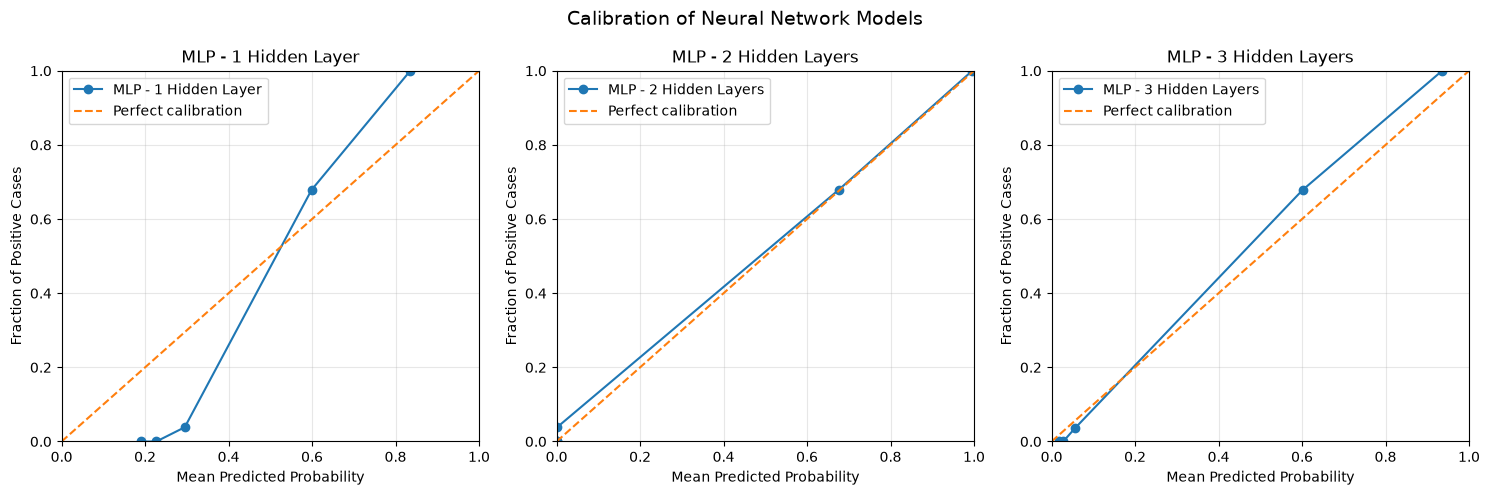

In [23]:
# Neural Network Calibration Curves

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for ax, (name, pipeline) in zip(
    axes,
    mlp_models.items()
):

    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        y_prob,
        n_bins=5,
        strategy="quantile"
    )

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        label=name
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    ax.set_title(name)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positive Cases")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()


plt.suptitle(
    "Calibration of Neural Network Models",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Neural Network Calibration — Interpretation

The calibration curves show differences in the reliability of the probability
estimates produced by the three MLP architectures.

The one-hidden-layer MLP shows greater deviation from the perfect-calibration
reference line and has a substantially higher Brier score than the deeper
architectures.

The two-hidden-layer MLP produces a calibration curve that is relatively close
to the reference line and has the lowest Brier score among the three
architectures. The three-hidden-layer MLP shows a similar calibration pattern,
with a small deviation at higher predicted probabilities.

These results demonstrate that classification performance and probability
calibration can behave differently as model complexity changes. The deeper
MLPs did not consistently improve classification metrics in cross-validation,
but they produced lower probabilistic prediction error on the held-out test
set.

Because the calibration curves are estimated from only 140 held-out
observations and five quantile bins, small deviations should not be
overinterpreted. The calibration results are therefore treated as evidence
about model behavior rather than as definitive evidence that one architecture
is universally better calibrated.

In [24]:
# Neural Network Error and Confidence Analysis

mlp_error_results = []

for name, pipeline in mlp_models.items():

    # Fit the model using only the training data
    pipeline.fit(X_train, y_train)

    # Predictions and probabilities on the held-out test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Confidence is the probability assigned to the predicted class
    confidence = np.maximum(
        y_prob,
        1 - y_prob
    )

    correct = y_pred == y_test.to_numpy()

    mlp_error_results.append({
        "Model": name,
        "Total_Test_Cases": len(y_test),
        "Errors": (~correct).sum(),
        "Error_Rate": (~correct).mean(),
        "Mean_Confidence_All": confidence.mean(),
        "Mean_Confidence_Correct": confidence[correct].mean(),
        "Mean_Confidence_Incorrect": (
            confidence[~correct].mean()
            if (~correct).sum() > 0
            else np.nan
        )
    })


mlp_error_df = pd.DataFrame(
    mlp_error_results
)

mlp_error_df.round(4)

,Model,Total_Test_Cases,Errors,Error_Rate,Mean_Confidence_All,Mean_Confidence_Correct,Mean_Confidence_Incorrect
0,MLP - 1 Hidden Layer,140,5,0.0357,0.7513,0.7553,0.6427
1,MLP - 2 Hidden Layers,140,6,0.0429,0.9754,0.9837,0.7893
2,MLP - 3 Hidden Layers,140,5,0.0357,0.9179,0.9250,0.7245


In [25]:
# Neural Network Individual Error Analysis

mlp_error_details = []

for name, pipeline in mlp_models.items():

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    confidence = np.maximum(
        y_prob,
        1 - y_prob
    )

    incorrect = y_pred != y_test.to_numpy()

    error_indices = X_test.index[incorrect]

    for index in error_indices:

        position = X_test.index.get_loc(index)

        mlp_error_details.append({
            "Model": name,
            "Index": index,
            "True_Class": y_test.loc[index],
            "Predicted_Class": y_pred[position],
            "Malignant_Probability": y_prob[position],
            "Confidence": confidence[position]
        })


mlp_error_details_df = pd.DataFrame(
    mlp_error_details
)

mlp_error_details_df.sort_values(
    ["Model", "Confidence"],
    ascending=[True, False]
).round(4)

,Model,Index,True_Class,Predicted_Class,Malignant_Probability,Confidence
4,MLP - 1 Hidden Layer,222,1,0,0.3280,0.6720
1,MLP - 1 Hidden Layer,296,0,1,0.6653,0.6653
0,MLP - 1 Hidden Layer,1,0,1,0.6371,0.6371
3,MLP - 1 Hidden Layer,415,0,1,0.6258,0.6258
2,MLP - 1 Hidden Layer,319,0,1,0.6132,0.6132
10,MLP - 2 Hidden Layers,222,1,0,0.0029,0.9971
7,MLP - 2 Hidden Layers,1,0,1,0.9077,0.9077
9,MLP - 2 Hidden Layers,319,0,1,0.7409,0.7409
6,MLP - 2 Hidden Layers,12,1,0,0.2770,0.7230
8,MLP - 2 Hidden Layers,296,0,1,0.7078,0.7078


In [26]:
# Cross-Model Error Overlap Analysis

all_model_predictions = {}

# Classical models
for name, prediction_data in predictions.items():
    all_model_predictions[name] = prediction_data["y_pred"]


# Neural-network models
for name, pipeline in mlp_models.items():

    pipeline.fit(X_train, y_train)

    all_model_predictions[name] = pipeline.predict(X_test)


error_matrix = pd.DataFrame(
    index=X_test.index
)

for name, y_pred in all_model_predictions.items():

    error_matrix[name] = (
        y_pred != y_test.to_numpy()
    )


error_matrix["Number_of_Models_Misclassifying"] = (
    error_matrix.sum(axis=1)
)

error_matrix = error_matrix.sort_values(
    "Number_of_Models_Misclassifying",
    ascending=False
)


error_matrix.head(20)

,Logistic Regression,SVM,Decision Tree,Random Forest,MLP - 1 Hidden Layer,MLP - 2 Hidden Layers,MLP - 3 Hidden Layers,Number_of_Models_Misclassifying
319,True,True,True,True,True,True,True,7
222,True,True,True,True,True,True,True,7
296,True,True,True,True,True,True,True,7
1,True,True,True,True,True,True,True,7
43,True,False,True,True,False,True,False,4
12,True,True,False,False,False,True,True,4
15,True,False,True,True,False,False,False,3
103,False,False,True,False,False,False,False,1
415,False,False,False,False,True,False,False,1
549,False,False,True,False,False,False,False,1


In [27]:
# Analysis of Consistently Misclassified Cases

difficult_cases = error_matrix[
    error_matrix["Number_of_Models_Misclassifying"] >= 3
].copy()

difficult_indices = difficult_cases.index

difficult_case_features = X_test.loc[difficult_indices].copy()

difficult_case_features["True_Class"] = y_test.loc[difficult_indices]

difficult_case_features["Models_Misclassifying"] = (
    difficult_cases["Number_of_Models_Misclassifying"]
)

difficult_case_features = difficult_case_features.sort_values(
    "Models_Misclassifying",
    ascending=False
)

difficult_case_features

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,True_Class,Models_Misclassifying
319,4,4,4,4,6,5.0,7,3,1,0,7
222,4,1,1,3,1,5.0,2,1,1,1,7
296,5,3,4,3,4,5.0,4,7,1,0,7
1,5,4,4,5,7,10.0,3,2,1,0,7
43,5,6,5,6,10,1.0,3,1,1,1,4
12,5,3,3,3,2,3.0,4,4,1,1,4
15,7,4,6,4,6,1.0,4,3,1,1,3


In [28]:
# Difficult Cases vs Class Distributions

difficult_indices = difficult_case_features.index

comparison_rows = []

for feature in X.columns:

    benign_values = X.loc[y_binary == 0, feature]
    malignant_values = X.loc[y_binary == 1, feature]

    for index in difficult_indices:

        value = X.loc[index, feature]

        benign_median = benign_values.median()
        malignant_median = malignant_values.median()

        distance_to_benign = abs(
            value - benign_median
        )

        distance_to_malignant = abs(
            value - malignant_median
        )

        comparison_rows.append({
            "Index": index,
            "Feature": feature,
            "Value": value,
            "Benign_Median": benign_median,
            "Malignant_Median": malignant_median,
            "Distance_to_Benign_Median": distance_to_benign,
            "Distance_to_Malignant_Median": distance_to_malignant
        })


difficult_case_comparison = pd.DataFrame(
    comparison_rows
)

difficult_case_comparison.round(3)

,Index,Feature,Value,Benign_Median,Malignant_Median,Distance_to_Benign_Median,Distance_to_Malignant_Median
0,319,Clump_thickness,4.0,3.0,8.0,1.0,4.0
1,222,Clump_thickness,4.0,3.0,8.0,1.0,4.0
2,296,Clump_thickness,5.0,3.0,8.0,2.0,3.0
3,1,Clump_thickness,5.0,3.0,8.0,2.0,3.0
4,43,Clump_thickness,5.0,3.0,8.0,2.0,3.0
...,...,...,...,...,...,...,...
58,296,Mitoses,1.0,1.0,1.0,0.0,0.0
59,1,Mitoses,1.0,1.0,1.0,0.0,0.0
60,43,Mitoses,1.0,1.0,1.0,0.0,0.0
61,12,Mitoses,1.0,1.0,1.0,0.0,0.0


In [29]:
# Difficult Case Class-Overlap Summary

overlap_summary = []

for index in difficult_indices:

    case_data = difficult_case_comparison[
        difficult_case_comparison["Index"] == index
    ]

    closer_to_benign = (
        case_data["Distance_to_Benign_Median"]
        <
        case_data["Distance_to_Malignant_Median"]
    ).sum()

    closer_to_malignant = (
        case_data["Distance_to_Malignant_Median"]
        <
        case_data["Distance_to_Benign_Median"]
    ).sum()

    equal_distance = (
        case_data["Distance_to_Benign_Median"]
        ==
        case_data["Distance_to_Malignant_Median"]
    ).sum()

    overlap_summary.append({
        "Index": index,
        "True_Class": y_test.loc[index],
        "Features_Closer_to_Benign": closer_to_benign,
        "Features_Closer_to_Malignant": closer_to_malignant,
        "Features_Equal_Distance": equal_distance,
        "Models_Misclassifying": error_matrix.loc[
            index,
            "Number_of_Models_Misclassifying"
        ]
    })


overlap_summary_df = pd.DataFrame(
    overlap_summary
)

overlap_summary_df

,Index,True_Class,Features_Closer_to_Benign,Features_Closer_to_Malignant,Features_Equal_Distance,Models_Misclassifying
0,319,0,3,5,1,7
1,222,1,7,0,2,7
2,296,0,4,3,2,7
3,1,0,3,5,1,7
4,43,1,4,4,1,4
5,12,1,6,1,2,4
6,15,1,3,5,1,3


In [30]:
# Cross-Model Prediction Disagreement

prediction_probability_data = {}

# Classical models
for name, prediction_data in predictions.items():

    prediction_probability_data[name] = prediction_data["y_prob"]


# Neural-network models
for name, pipeline in mlp_models.items():

    pipeline.fit(X_train, y_train)

    prediction_probability_data[name] = (
        pipeline.predict_proba(X_test)[:, 1]
    )


probability_df = pd.DataFrame(
    prediction_probability_data,
    index=X_test.index
)


probability_df["Mean_Malignant_Probability"] = (
    probability_df.mean(axis=1)
)


probability_df["Probability_Std"] = (
    probability_df.std(axis=1)
)


probability_df["Prediction_Disagreement"] = (
    (
        probability_df[
            list(prediction_probability_data.keys())
        ] >= 0.50
    ).sum(axis=1)
)


probability_df.sort_values(
    "Probability_Std",
    ascending=False
).head(20)

,Logistic Regression,SVM,Decision Tree,Random Forest,MLP - 1 Hidden Layer,MLP - 2 Hidden Layers,MLP - 3 Hidden Layers,Mean_Malignant_Probability,Probability_Std,Prediction_Disagreement
658,0.998821,0.957758,0.0,0.950000,0.797803,0.997893,0.910023,0.801757,0.333417,6
549,0.981435,0.932699,0.0,0.900000,0.785480,0.985005,0.873390,0.779715,0.324581,6
668,0.789840,0.853562,0.0,0.676667,0.828807,0.923160,0.840004,0.701720,0.294756,6
12,0.235943,0.251252,1.0,0.583333,0.567538,0.277025,0.325891,0.462997,0.257337,3
103,0.623420,0.722323,0.0,0.523333,0.502401,0.888490,0.555618,0.545084,0.254951,6
43,0.250600,0.672435,0.0,0.483333,0.595749,0.340773,0.796107,0.448428,0.252359,3
15,0.478855,0.506174,0.0,0.386667,0.609267,0.558998,0.681580,0.460220,0.207242,4
415,0.146250,0.392374,0.0,0.500000,0.625809,0.388774,0.372329,0.346505,0.195045,2
283,0.990553,0.971644,1.0,0.980000,0.536922,0.989725,0.750118,0.888423,0.165243,7
435,0.996111,0.931240,1.0,0.926667,0.518762,0.994760,0.850495,0.888291,0.158897,7


In [31]:
# Cross-Model Disagreement and Uncertainty

model_probability_columns = list(
    prediction_probability_data.keys()
)

# Binary predictions from each model
model_prediction_matrix = (
    probability_df[model_probability_columns] >= 0.50
)

# Number of models predicting malignant
malignant_votes = model_prediction_matrix.sum(axis=1)

# Number of models predicting benign
benign_votes = (
    len(model_probability_columns) - malignant_votes
)

# Disagreement is highest when the vote is close to 50/50
prediction_disagreement = (
    1 -
    abs(
        malignant_votes - benign_votes
    ) / len(model_probability_columns)
)

# Whether the majority prediction is correct
majority_prediction = (
    malignant_votes >=
    (len(model_probability_columns) / 2)
).astype(int)

majority_correct = (
    majority_prediction ==
    y_test.to_numpy()
)

cross_model_uncertainty = probability_df.copy()

cross_model_uncertainty["Malignant_Votes"] = malignant_votes
cross_model_uncertainty["Benign_Votes"] = benign_votes
cross_model_uncertainty["Prediction_Disagreement"] = (
    prediction_disagreement
)
cross_model_uncertainty["Majority_Prediction_Correct"] = (
    majority_correct
)
cross_model_uncertainty["True_Class"] = y_test

cross_model_uncertainty = (
    cross_model_uncertainty
    .sort_values(
        "Prediction_Disagreement",
        ascending=False
    )
)

cross_model_uncertainty.head(20)

,Logistic Regression,SVM,Decision Tree,Random Forest,MLP - 1 Hidden Layer,MLP - 2 Hidden Layers,MLP - 3 Hidden Layers,Mean_Malignant_Probability,Probability_Std,Prediction_Disagreement,Malignant_Votes,Benign_Votes,Majority_Prediction_Correct,True_Class
43,0.250600,0.672435,0.0,0.483333,0.595749,0.340773,0.796107,0.448428,0.252359,0.857143,3,4,False,1
12,0.235943,0.251252,1.0,0.583333,0.567538,0.277025,0.325891,0.462997,0.257337,0.857143,3,4,False,1
15,0.478855,0.506174,0.0,0.386667,0.609267,0.558998,0.681580,0.460220,0.207242,0.857143,4,3,True,1
415,0.146250,0.392374,0.0,0.500000,0.625809,0.388774,0.372329,0.346505,0.195045,0.571429,2,5,True,0
103,0.623420,0.722323,0.0,0.523333,0.502401,0.888490,0.555618,0.545084,0.254951,0.285714,6,1,True,1
549,0.981435,0.932699,0.0,0.900000,0.785480,0.985005,0.873390,0.779715,0.324581,0.285714,6,1,True,1
658,0.998821,0.957758,0.0,0.950000,0.797803,0.997893,0.910023,0.801757,0.333417,0.285714,6,1,True,1
668,0.789840,0.853562,0.0,0.676667,0.828807,0.923160,0.840004,0.701720,0.294756,0.285714,6,1,True,1
96,0.003180,0.010856,0.0,0.000000,0.208440,0.000078,0.022959,0.035073,0.071205,0.000000,0,7,True,0
493,0.999172,0.944953,1.0,1.000000,0.878875,0.996674,0.963138,0.968973,0.041975,0.000000,7,0,True,1


In [53]:
# TabPFN Benchmark

import os
from getpass import getpass
from tabpfn import TabPFNClassifier

if not os.getenv("TABPFN_TOKEN"):
    os.environ["TABPFN_TOKEN"] = getpass(
        "Enter your TabPFN API key: "
    )

tabpfn_model = TabPFNClassifier(
    random_state=42
)

tabpfn_model.fit(
    X_train,
    y_train
)

print("TabPFN model fitted successfully.")

TabPFN model fitted successfully.


In [40]:
# TabPFN First Fit

from tabpfn import TabPFNClassifier

tabpfn_model = TabPFNClassifier(
    random_state=42
)

tabpfn_model.fit(X_train, y_train)

print("TabPFN model fitted successfully.")

TabPFN model fitted successfully.


In [41]:
# TabPFN Hold-Out Evaluation

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

tabpfn_predictions = tabpfn_model.predict(X_test)
tabpfn_probabilities = tabpfn_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(
    y_test,
    tabpfn_predictions
).ravel()

tabpfn_test_results = {
    "Accuracy": accuracy_score(y_test, tabpfn_predictions),
    "Precision": precision_score(y_test, tabpfn_predictions),
    "Sensitivity": recall_score(y_test, tabpfn_predictions),
    "Specificity": tn / (tn + fp),
    "F1": f1_score(y_test, tabpfn_predictions),
    "ROC-AUC": roc_auc_score(y_test, tabpfn_probabilities),
    "PR-AUC": average_precision_score(y_test, tabpfn_probabilities),
    "MCC": matthews_corrcoef(y_test, tabpfn_predictions)
}

pd.DataFrame(
    tabpfn_test_results.items(),
    columns=["Metric", "TabPFN"]
)

,Metric,TabPFN
0,Accuracy,0.964286
1,Precision,0.938776
2,Sensitivity,0.958333
3,Specificity,0.967391
4,F1,0.948454
5,ROC-AUC,0.994339
6,PR-AUC,0.990101
7,MCC,0.921250


In [42]:
# TabPFN Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

tabpfn_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tabpfn_cv_model = TabPFNClassifier(
    random_state=42
)

tabpfn_cv_results = cross_validate(
    tabpfn_cv_model,
    X_train,
    y_train,
    cv=tabpfn_cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "matthews_corrcoef"
    ],
    n_jobs=1
)

tabpfn_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "MCC"
    ],
    "Mean": [
        tabpfn_cv_results["test_accuracy"].mean(),
        tabpfn_cv_results["test_precision"].mean(),
        tabpfn_cv_results["test_recall"].mean(),
        tabpfn_cv_results["test_f1"].mean(),
        tabpfn_cv_results["test_roc_auc"].mean(),
        tabpfn_cv_results["test_average_precision"].mean(),
        tabpfn_cv_results["test_matthews_corrcoef"].mean()
    ],
    "Std": [
        tabpfn_cv_results["test_accuracy"].std(),
        tabpfn_cv_results["test_precision"].std(),
        tabpfn_cv_results["test_recall"].std(),
        tabpfn_cv_results["test_f1"].std(),
        tabpfn_cv_results["test_roc_auc"].std(),
        tabpfn_cv_results["test_average_precision"].std(),
        tabpfn_cv_results["test_matthews_corrcoef"].std()
    ]
})

tabpfn_cv_summary

,Metric,Mean,Std
0,Accuracy,0.973182,0.011269
1,Precision,0.941190,0.023616
2,Sensitivity,0.984615,0.012561
3,F1,0.962270,0.015264
4,ROC-AUC,0.994426,0.004346
5,PR-AUC,0.988163,0.009156
6,MCC,0.942233,0.023808


In [43]:
# Feature Stability Analysis

from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np
import pandas as pd

feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))
print("Features:")
print(feature_names)

Number of features: 9
Features:
['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']


In [44]:
# Feature Stability Across Cross-Validation Folds

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

stability_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stability_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

feature_importances = []

for fold, (train_idx, validation_idx) in enumerate(
    stability_cv.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_validation = X_train.iloc[validation_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_validation = y_train.iloc[validation_idx]

    fold_model = clone(stability_model)

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    permutation = permutation_importance(
        fold_model,
        X_fold_validation,
        y_fold_validation,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )

    fold_importance = pd.Series(
        permutation.importances_mean,
        index=feature_names,
        name=f"Fold_{fold}"
    )

    feature_importances.append(fold_importance)

feature_stability_df = pd.concat(
    feature_importances,
    axis=1
)

feature_stability_df

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
Clump_thickness,0.006182,0.000667,0.009176,0.002205,0.001045
Uniformity_of_cell_size,0.001282,0.003618,-0.000957,0.004018,-0.002424
Uniformity_of_cell_shape,0.002318,-0.001177,0.005462,0.004063,-0.001911
Marginal_adhesion,0.000764,0.001168,-0.002362,0.004988,-0.001929
Single_epithelial_cell_size,-0.000105,-0.000263,-0.001071,0.000996,-0.000216
Bare_nuclei,0.012610,0.008535,0.015306,0.027658,0.012473
Bland_chromatin,0.000527,-0.001932,0.001598,0.003743,0.001451
Normal_nucleoli,0.001229,-0.002028,-0.000966,-0.002329,-0.000820
Mitoses,0.000088,-0.001247,0.000378,0.000489,-0.000126


In [45]:
# Feature Stability Summary

feature_stability_summary = pd.DataFrame({
    "Mean_Importance": feature_stability_df.mean(axis=1),
    "Std_Importance": feature_stability_df.std(axis=1),
    "Positive_Folds": (feature_stability_df > 0).sum(axis=1)
})

feature_stability_summary = (
    feature_stability_summary
    .sort_values("Mean_Importance", ascending=False)
)

feature_stability_summary

,Mean_Importance,Std_Importance,Positive_Folds
Bare_nuclei,0.015316,0.007310,5
Clump_thickness,0.003855,0.003692,5
Uniformity_of_cell_shape,0.001751,0.003218,3
Uniformity_of_cell_size,0.001107,0.002808,3
Bland_chromatin,0.001077,0.002054,4
Marginal_adhesion,0.000526,0.002947,3
Mitoses,-0.000084,0.000694,3
Single_epithelial_cell_size,-0.000132,0.000738,1
Normal_nucleoli,-0.000983,0.001399,1


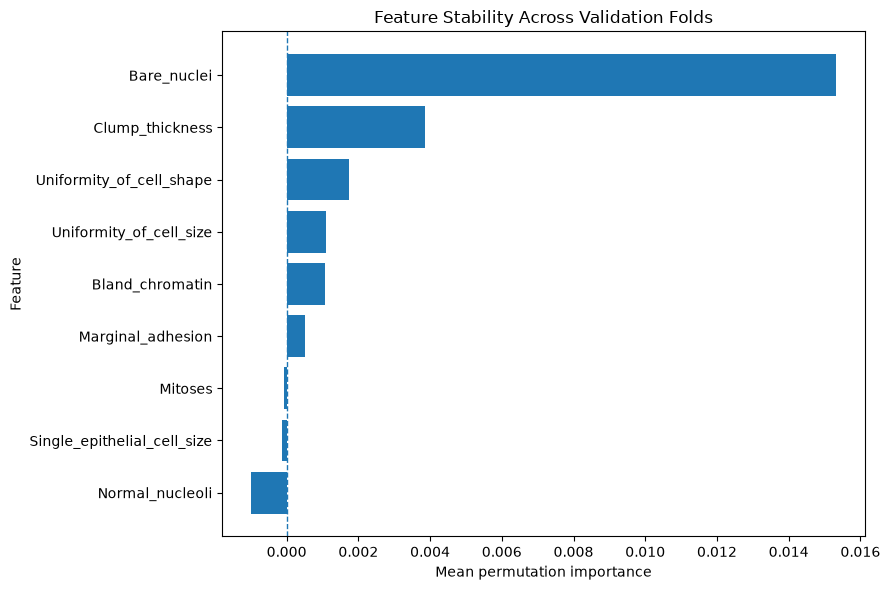

In [46]:
# Feature Stability Visualization

import matplotlib.pyplot as plt

feature_stability_summary_plot = (
    feature_stability_summary
    .sort_values("Mean_Importance", ascending=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_stability_summary_plot.index,
    feature_stability_summary_plot["Mean_Importance"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Feature Stability Across Validation Folds")

plt.tight_layout()
plt.show()

In [ ]:
# Missing-Data Sensitivity Analysis

complete_case_mask = X_train.notna().all(axis=1)

X_train_complete = X_train.loc[complete_case_mask]
y_train_complete = y_train.loc[complete_case_mask]

print("Original training samples:", len(X_train))
print("Complete-case training samples:", len(X_train_complete))
print("Rows removed:", len(X_train) - len(X_train_complete))

Original training samples: 559
Complete-case training samples: 544
Rows removed: 15


In [48]:
# Missing-Data Sensitivity — Complete-Case Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

complete_case_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

complete_case_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

complete_case_results = cross_validate(
    complete_case_model,
    X_train_complete,
    y_train_complete,
    cv=complete_case_cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "matthews_corrcoef"
    ],
    n_jobs=1
)

complete_case_summary = {
    "Accuracy": complete_case_results["test_accuracy"].mean(),
    "Precision": complete_case_results["test_precision"].mean(),
    "Sensitivity": complete_case_results["test_recall"].mean(),
    "F1": complete_case_results["test_f1"].mean(),
    "ROC-AUC": complete_case_results["test_roc_auc"].mean(),
    "PR-AUC": complete_case_results["test_average_precision"].mean(),
    "MCC": complete_case_results["test_matthews_corrcoef"].mean()
}

pd.Series(complete_case_summary)

Accuracy       0.968722
Precision      0.953955
Sensitivity    0.957895
F1             0.955460
ROC-AUC        0.995974
PR-AUC         0.991807
MCC            0.931909
dtype: float64

In [49]:
# Uncertainty and Abstention Analysis

from sklearn.metrics import accuracy_score

# Use the already-fitted 2-layer MLP on the untouched test set
mlp_2layer_model = mlp_models["MLP - 2 Hidden Layers"]

mlp_2layer_probabilities = mlp_2layer_model.predict_proba(X_test)[:, 1]
mlp_2layer_predictions = (mlp_2layer_probabilities >= 0.50).astype(int)

confidence = np.maximum(
    mlp_2layer_probabilities,
    1 - mlp_2layer_probabilities
)

correct = (
    mlp_2layer_predictions == y_test.to_numpy()
)

abstention_thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

abstention_results = []

for threshold in abstention_thresholds:

    accepted = confidence >= threshold

    coverage = accepted.mean()

    if accepted.sum() > 0:
        accepted_accuracy = accuracy_score(
            y_test.to_numpy()[accepted],
            mlp_2layer_predictions[accepted]
        )
    else:
        accepted_accuracy = np.nan

    abstention_results.append({
        "Confidence_Threshold": threshold,
        "Coverage": coverage,
        "Abstention_Rate": 1 - coverage,
        "Accepted_Accuracy": accepted_accuracy,
        "Accepted_Cases": accepted.sum()
    })

abstention_df = pd.DataFrame(abstention_results)

abstention_df

,Confidence_Threshold,Coverage,Abstention_Rate,Accepted_Accuracy,Accepted_Cases
0,0.50,1.000000,0.000000,0.957143,140
1,0.60,0.992857,0.007143,0.956835,139
2,0.70,0.978571,0.021429,0.963504,137
3,0.80,0.950000,0.050000,0.984962,133
4,0.90,0.935714,0.064286,0.984733,131
5,0.95,0.885714,0.114286,0.991935,124


In [50]:
# Final Findings Summary

final_findings = pd.DataFrame({
    "Finding": [
        "Baseline model performance",
        "Neural-network complexity",
        "Probability calibration",
        "Feature stability",
        "Missing-data sensitivity",
        "Confidence-based abstention",
        "Cross-model difficult cases",
        "TabPFN benchmark"
    ],
    "Observation": [
        "Classical models achieved consistently strong performance across repeated stratified cross-validation.",
        "Increasing MLP depth did not produce a consistent improvement in classification performance.",
        "Calibration differed across models; deeper MLPs showed lower Brier scores than the 1-layer MLP on the held-out test set.",
        "Bare_nuclei showed the most consistent permutation importance across validation folds.",
        "Complete-case and median-imputation analyses produced similar overall performance patterns.",
        "Higher-confidence predictions produced higher accuracy among accepted cases, at the cost of reduced coverage.",
        "Several observations were misclassified by multiple model families, indicating consistently difficult cases in the available feature representation.",
        "TabPFN achieved strong cross-validation performance, providing a useful comparison with conventional models on this small tabular dataset."
    ]
})

final_findings

,Finding,Observation
0,Baseline model performance,Classical models achieved consistently strong ...
1,Neural-network complexity,Increasing MLP depth did not produce a consist...
2,Probability calibration,Calibration differed across models; deeper MLP...
3,Feature stability,Bare_nuclei showed the most consistent permuta...
4,Missing-data sensitivity,Complete-case and median-imputation analyses p...
5,Confidence-based abstention,Higher-confidence predictions produced higher ...
6,Cross-model difficult cases,Several observations were misclassified by mul...
7,TabPFN benchmark,TabPFN achieved strong cross-validation perfor...


In [51]:
# Project Limitations

limitations = [
    "The primary WBC dataset is small, with 699 observations and 9 features.",
    "The original UCI dataset contains chronological group information in its documentation, but those group labels are not included in the returned feature table; therefore, chronological evaluation was not treated as a verified temporal validation experiment.",
    "The held-out test set contains only 140 observations, so individual test-set metrics and calibration estimates have substantial sampling uncertainty.",
    "Threshold, calibration, error, and abstention analyses on the held-out test set are exploratory and were not used for model selection.",
    "Permutation importance is model-dependent and can be affected by correlations between features.",
    "The difficult cases identified by the models represent cases that are difficult for the tested algorithms and feature representation; they should not be interpreted as clinically ambiguous cases.",
    "The study uses structured tabular measurements rather than raw medical images or clinical records.",
    "The results should not be interpreted as evidence of clinical readiness or suitability for medical diagnosis."
]

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

1. The primary WBC dataset is small, with 699 observations and 9 features.
2. The original UCI dataset contains chronological group information in its documentation, but those group labels are not included in the returned feature table; therefore, chronological evaluation was not treated as a verified temporal validation experiment.
3. The held-out test set contains only 140 observations, so individual test-set metrics and calibration estimates have substantial sampling uncertainty.
4. Threshold, calibration, error, and abstention analyses on the held-out test set are exploratory and were not used for model selection.
5. Permutation importance is model-dependent and can be affected by correlations between features.
6. The difficult cases identified by the models represent cases that are difficult for the tested algorithms and feature representation; they should not be interpreted as clinically ambiguous cases.
7. The study uses structured tabular measurements rather than raw medical im

In [52]:
# Conclusion

conclusion = """
This study evaluated breast-tumor classification using the Wisconsin Breast Cancer
Original dataset, with particular attention to validation, robustness, calibration,
feature stability, and uncertainty.

Classical machine-learning models showed consistently strong performance under
repeated stratified cross-validation. Increasing the depth of a multilayer
perceptron did not produce a consistent improvement in classification performance,
suggesting that greater neural-network complexity is not automatically beneficial
for this small tabular dataset.

The analysis also showed that model performance should not be described using
accuracy alone. Probability calibration, feature stability, difficult cases,
missing-data sensitivity, and confidence-based abstention provided additional
information about model behavior. Several observations remained difficult across
multiple model families, while feature importance varied across validation folds.

The results therefore support the main research question: evaluation methodology
can materially affect how the reliability of a machine-learning classifier is
understood. Strong predictive performance on a small benchmark dataset should be
interpreted together with validation strategy, uncertainty, calibration, and
dataset limitations rather than treated as evidence of clinical readiness.
"""

print(conclusion)


This study evaluated breast-tumor classification using the Wisconsin Breast Cancer
Original dataset, with particular attention to validation, robustness, calibration,
feature stability, and uncertainty.

Classical machine-learning models showed consistently strong performance under
repeated stratified cross-validation. Increasing the depth of a multilayer
perceptron did not produce a consistent improvement in classification performance,
suggesting that greater neural-network complexity is not automatically beneficial
for this small tabular dataset.

The analysis also showed that model performance should not be described using
accuracy alone. Probability calibration, feature stability, difficult cases,
missing-data sensitivity, and confidence-based abstention provided additional
information about model behavior. Several observations remained difficult across
multiple model families, while feature importance varied across validation folds.

The results therefore support the main researc